In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

PROCESSED = Path("../../data/processed")
RAW = Path("../../data/raw")
print("Imports OK")

Imports OK


In [2]:
ob_files = sorted(RAW.glob("orderbooks/orderbooks_depth_*.json"))
print(f"Orderbook files: {len(ob_files)}")

all_snapshots = []
for f in ob_files:
    with open(f) as fp:
        data = json.load(fp)

        file_ts = f.stem.split("_", 2)[-1]
        for snap in data:
            snap["_file_ts"] = file_ts
        all_snapshots.extend(data)

n_rounds = len(ob_files)
n_unique_tokens = len(set(s["token_id"] for s in all_snapshots))
print(f"Total snapshots: {len(all_snapshots)} ({n_rounds} rounds × {n_unique_tokens} unique tokens)")

prices = pd.read_parquet(PROCESSED / "prices.parquet")
prices["datetime"] = pd.to_datetime(prices["datetime"], utc=True)
print(f"Prices: {prices.shape[0]:,} rows, {prices.token_id.nunique()} tokens")

trades = pd.read_parquet(PROCESSED / "trades.parquet")
trades["datetime"] = pd.to_datetime(trades["datetime"], utc=True)
print(f"Trades: {trades.shape[0]:,} rows, {trades.conditionId.nunique()} markets")

Orderbook files: 2
Total snapshots: 200 (2 rounds × 100 unique tokens)
Prices: 198,493 rows, 100 tokens
Trades: 154,819 rows, 50 markets


In [3]:
ob_stats = []
for snap in all_snapshots:
    bids = snap.get("bids", [])
    asks = snap.get("asks", [])

    bids_sorted = sorted(bids, key=lambda x: float(x["price"]), reverse=True)
    asks_sorted = sorted(asks, key=lambda x: float(x["price"]))

    best_bid = float(bids_sorted[0]["price"]) if bids_sorted else 0
    best_ask = float(asks_sorted[0]["price"]) if asks_sorted else 1

    bid_depth_total = sum(float(b["size"]) * float(b["price"]) for b in bids)
    ask_depth_total = sum(float(a["size"]) * float(a["price"]) for a in asks)

    bid_depth_5c = sum(float(b["size"]) * float(b["price"])
                       for b in bids_sorted if float(b["price"]) >= best_bid - 0.05)
    ask_depth_5c = sum(float(a["size"]) * float(a["price"])
                       for a in asks_sorted if float(a["price"]) <= best_ask + 0.05)

    ob_stats.append({
        "token_id": snap["token_id"],
        "condition_id": snap["condition_id"],
        "title": snap.get("title", ""),
        "file_ts": snap.get("_file_ts", ""),
        "best_bid": best_bid,
        "best_ask": best_ask,
        "spread": best_ask - best_bid,
        "n_bids": len(bids),
        "n_asks": len(asks),
        "bid_depth_total": bid_depth_total,
        "ask_depth_total": ask_depth_total,
        "bid_depth_5c": bid_depth_5c,
        "ask_depth_5c": ask_depth_5c,
        "midpoint": (best_bid + best_ask) / 2,
    })

ob_df = pd.DataFrame(ob_stats)
print(f"Orderbook stats: {len(ob_df)} snapshots, {ob_df.token_id.nunique()} unique tokens, {ob_df.file_ts.nunique()} rounds")
print(f"\nSpread: mean={ob_df.spread.mean():.4f}, median={ob_df.spread.median():.4f}")
print(f"Bid depth (5c): mean=${ob_df.bid_depth_5c.mean():,.0f}, median=${ob_df.bid_depth_5c.median():,.0f}")
print(f"Ask depth (5c): mean=${ob_df.ask_depth_5c.mean():,.0f}, median=${ob_df.ask_depth_5c.median():,.0f}")

if ob_df.file_ts.nunique() > 1:
    depth_var = ob_df.groupby("token_id")["bid_depth_5c"].agg(["mean", "std"])
    depth_var["cv"] = depth_var["std"] / depth_var["mean"].clip(lower=1)
    print(f"\nDepth variability (CV across rounds): median={depth_var['cv'].median():.3f}, mean={depth_var['cv'].mean():.3f}")

ob_df[["spread", "bid_depth_5c", "ask_depth_5c", "midpoint"]].describe()

Orderbook stats: 200 snapshots, 100 unique tokens, 2 rounds

Spread: mean=0.0055, median=0.0020
Bid depth (5c): mean=$143,331, median=$45,241
Ask depth (5c): mean=$376,693, median=$45,537

Depth variability (CV across rounds): median=0.002, mean=0.030


,spread,bid_depth_5c,ask_depth_5c,midpoint
count,200.000000,2.000000e+02,2.000000e+02,200.000000
mean,0.005475,1.433307e+05,3.766928e+05,0.500003
std,0.005467,2.365428e+05,1.414369e+06,0.327440
min,0.001000,7.894640e+01,9.985700e+01,0.050500
25%,0.001000,1.048049e+04,1.285619e+04,0.162625
50%,0.002000,4.524067e+04,4.553734e+04,0.500000
75%,0.010000,1.702640e+05,1.992879e+05,0.837375
max,0.029000,1.509987e+06,1.322512e+07,0.949500


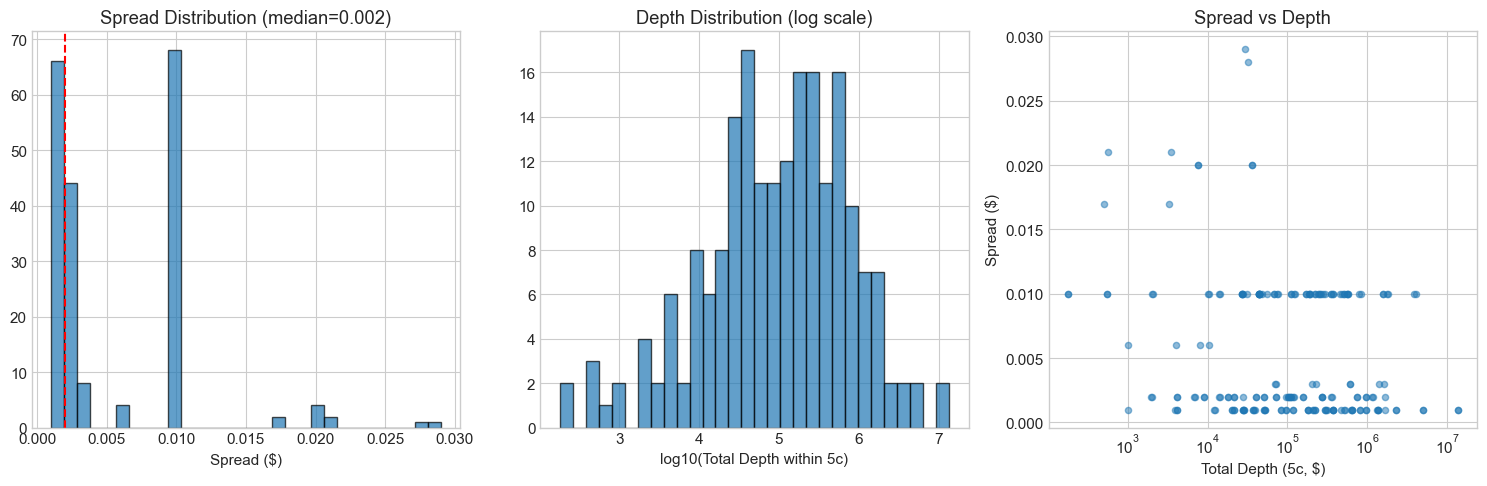

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(ob_df["spread"], bins=30, edgecolor="k", alpha=0.7)
axes[0].set_xlabel("Spread ($)")
axes[0].set_title(f"Spread Distribution (median={ob_df.spread.median():.3f})")
axes[0].axvline(ob_df.spread.median(), color="r", ls="--")

depth_5c = ob_df["bid_depth_5c"] + ob_df["ask_depth_5c"]
axes[1].hist(np.log10(depth_5c.clip(lower=1)), bins=30, edgecolor="k", alpha=0.7)
axes[1].set_xlabel("log10(Total Depth within 5c)")
axes[1].set_title("Depth Distribution (log scale)")

axes[2].scatter(depth_5c, ob_df["spread"], alpha=0.5, s=20)
axes[2].set_xscale("log")
axes[2].set_xlabel("Total Depth (5c, $)")
axes[2].set_ylabel("Spread ($)")
axes[2].set_title("Spread vs Depth")

plt.tight_layout()
plt.show()

In [5]:
def simulate_market_order(levels: list[dict], order_usd: float, side: str) -> dict:
    """Simulate market order execution walking through orderbook levels.

    Args:
        levels: sorted list of {price, size} dicts
            BUY: asks sorted ascending by price
            SELL: bids sorted descending by price
        order_usd: total dollar amount to execute
        side: 'BUY' or 'SELL'

    Returns:
        dict with avg_price, worst_price, slippage_pct, filled_pct
    """
    if not levels:
        return {"avg_price": np.nan, "worst_price": np.nan,
                "slippage_pct": np.nan, "filled_pct": 0.0}

    best_price = float(levels[0]["price"])
    remaining_usd = order_usd
    total_shares = 0
    total_cost = 0
    worst_price = best_price

    for level in levels:
        price = float(level["price"])
        size = float(level["size"])
        level_usd = size * price

        if level_usd <= remaining_usd:

            total_shares += size
            total_cost += level_usd
            remaining_usd -= level_usd
            worst_price = price
        else:

            shares_at_level = remaining_usd / price
            total_shares += shares_at_level
            total_cost += remaining_usd
            worst_price = price
            remaining_usd = 0
            break

    if total_shares == 0:
        return {"avg_price": np.nan, "worst_price": np.nan,
                "slippage_pct": np.nan, "filled_pct": 0.0}

    avg_price = total_cost / total_shares
    filled_pct = (order_usd - remaining_usd) / order_usd

    if side == "BUY":
        slippage_pct = (avg_price - best_price) / best_price * 100
    else:
        slippage_pct = (best_price - avg_price) / best_price * 100

    return {
        "avg_price": avg_price,
        "worst_price": worst_price,
        "slippage_pct": slippage_pct,
        "filled_pct": filled_pct,
        "total_shares": total_shares,
        "total_cost": total_cost,
    }

ORDER_SIZES = [10, 50, 100, 500, 1000, 5000]
results = []

for snap in all_snapshots:
    bids = sorted(snap["bids"], key=lambda x: float(x["price"]), reverse=True)
    asks = sorted(snap["asks"], key=lambda x: float(x["price"]))

    best_bid = float(bids[0]["price"]) if bids else 0
    best_ask = float(asks[0]["price"]) if asks else 1
    midpoint = (best_bid + best_ask) / 2
    spread = best_ask - best_bid

    bid_depth = sum(float(b["size"]) * float(b["price"]) for b in bids)
    ask_depth = sum(float(a["size"]) * float(a["price"]) for a in asks)
    total_depth = bid_depth + ask_depth

    for order_usd in ORDER_SIZES:

        buy_result = simulate_market_order(asks, order_usd, "BUY")

        sell_result = simulate_market_order(bids, order_usd, "SELL")

        results.append({
            "token_id": snap["token_id"],
            "title": snap.get("title", ""),
            "midpoint": midpoint,
            "spread": spread,
            "total_depth": total_depth,
            "order_usd": order_usd,
            "buy_slippage_pct": buy_result["slippage_pct"],
            "sell_slippage_pct": sell_result["slippage_pct"],
            "buy_filled_pct": buy_result["filled_pct"],
            "sell_filled_pct": sell_result["filled_pct"],
            "avg_slippage_pct": np.nanmean([buy_result["slippage_pct"], sell_result["slippage_pct"]]),
        })

slip_df = pd.DataFrame(results)
print(f"Slippage simulations: {len(slip_df)} ({len(all_snapshots)} tokens x {len(ORDER_SIZES)} sizes)")
print("\nMedian slippage by order size:")
print(slip_df.groupby("order_usd")["avg_slippage_pct"].agg(["median", "mean", "max"]).round(3))

Slippage simulations: 1200 (200 tokens x 6 sizes)

Median slippage by order size:
           median    mean      max
order_usd                         
10          0.000   0.132    5.306
50          0.000   0.349    7.157
100         0.000   0.596   15.442
500         0.040   2.490   96.891
1000        0.101   4.163  116.142
5000        0.671  11.712  157.031


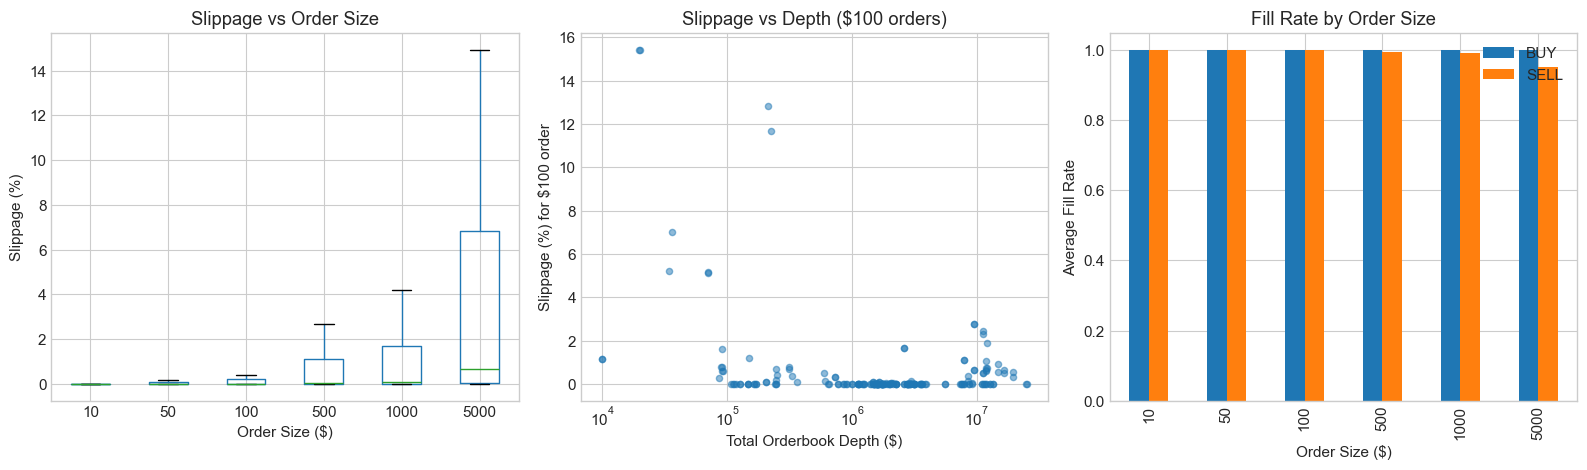

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

slip_df.boxplot(column="avg_slippage_pct", by="order_usd", ax=axes[0], showfliers=False)
axes[0].set_xlabel("Order Size ($)")
axes[0].set_ylabel("Slippage (%)")
axes[0].set_title("Slippage vs Order Size")
axes[0].get_figure().suptitle("")

s100 = slip_df[slip_df["order_usd"] == 100]
axes[1].scatter(s100["total_depth"], s100["avg_slippage_pct"], alpha=0.5, s=20)
axes[1].set_xscale("log")
axes[1].set_xlabel("Total Orderbook Depth ($)")
axes[1].set_ylabel("Slippage (%) for $100 order")
axes[1].set_title("Slippage vs Depth ($100 orders)")

fill_stats = slip_df.groupby("order_usd").agg(
    buy_fill=("buy_filled_pct", "mean"),
    sell_fill=("sell_filled_pct", "mean")
)
fill_stats.plot(kind="bar", ax=axes[2])
axes[2].set_xlabel("Order Size ($)")
axes[2].set_ylabel("Average Fill Rate")
axes[2].set_title("Fill Rate by Order Size")
axes[2].set_ylim(0, 1.05)
axes[2].legend(["BUY", "SELL"])

plt.tight_layout()
plt.show()

In [7]:
model_df = slip_df.dropna(subset=["avg_slippage_pct"]).copy()
model_df = model_df[model_df["avg_slippage_pct"] > 0]
model_df["order_depth_ratio"] = model_df["order_usd"] / model_df["total_depth"].clip(lower=1)

x = np.log10(model_df["order_depth_ratio"].clip(lower=1e-10))
y = np.log10(model_df["avg_slippage_pct"].clip(lower=1e-6))
mask = np.isfinite(x) & np.isfinite(y)

slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])
print(f"Model 1 (power law): log10(slip) = {intercept:.3f} + {slope:.3f} * log10(order/depth)")
print(f"  R² = {r_value**2:.3f}")

from sklearn.linear_model import LinearRegression

model_df["log_ratio"] = np.log10(model_df["order_depth_ratio"].clip(lower=1e-10))
model_df["log_slip"] = np.log10(model_df["avg_slippage_pct"].clip(lower=1e-6))

model_df["price_extremity"] = 4 * model_df["midpoint"] * (1 - model_df["midpoint"])

feat_cols = ["log_ratio", "midpoint", "price_extremity", "spread"]
mask2 = model_df[feat_cols + ["log_slip"]].replace([np.inf, -np.inf], np.nan).dropna().index
X = model_df.loc[mask2, feat_cols].values
y2 = model_df.loc[mask2, "log_slip"].values

lr = LinearRegression().fit(X, y2)
r2_multi = lr.score(X, y2)
print(f"\nModel 2 (multi-feature): R² = {r2_multi:.3f}")
print(f"  Features: {feat_cols}")
print(f"  Coefficients: {dict(zip(feat_cols, [f'{c:.3f}' for c in lr.coef_]))}")
print(f"  Intercept: {lr.intercept_:.3f}")

print("\n=== Practical Slippage Guide (Model 1: power law) ===")
print(f"{'Order $':>10} {'Depth $':>12} {'Ratio':>10} {'Slippage%':>12}")
print("-" * 50)
for order in [50, 100, 500, 1000, 5000]:
    for depth in [10000, 100000, 1000000]:
        ratio = order / depth
        pred_slip = 10**(intercept + slope * np.log10(ratio))
        print(f"{order:>10} {depth:>12,} {ratio:>10.5f} {pred_slip:>11.3f}%")

print("\n=== Max Order Size for <1% Slippage ===")

target_slip = 1.0
for depth in [1000, 10000, 100000, 1000000]:
    max_ratio = (target_slip / 10**intercept) ** (1 / slope)
    max_order = depth * max_ratio
    print(f"  Depth ${depth:>10,} → max order ${max_order:,.0f} (ratio {max_ratio:.4f})")

Model 1 (power law): log10(slip) = 1.520 + 0.718 * log10(order/depth)
  R² = 0.132



Model 2 (multi-feature): R² = 0.324
  Features: ['log_ratio', 'midpoint', 'price_extremity', 'spread']
  Coefficients: {'log_ratio': '1.065', 'midpoint': '-2.800', 'price_extremity': '0.163', 'spread': '-76.745'}
  Intercept: 4.277

=== Practical Slippage Guide (Model 1: power law) ===
   Order $      Depth $      Ratio    Slippage%
--------------------------------------------------
        50       10,000    0.00500       0.736%
        50      100,000    0.00050       0.141%
        50    1,000,000    0.00005       0.027%
       100       10,000    0.01000       1.212%
       100      100,000    0.00100       0.232%
       100    1,000,000    0.00010       0.044%
       500       10,000    0.05000       3.850%
       500      100,000    0.00500       0.736%
       500    1,000,000    0.00050       0.141%
      1000       10,000    0.10000       6.335%
      1000      100,000    0.01000       1.212%
      1000    1,000,000    0.00100       0.232%
      5000       10,000    0.50000   

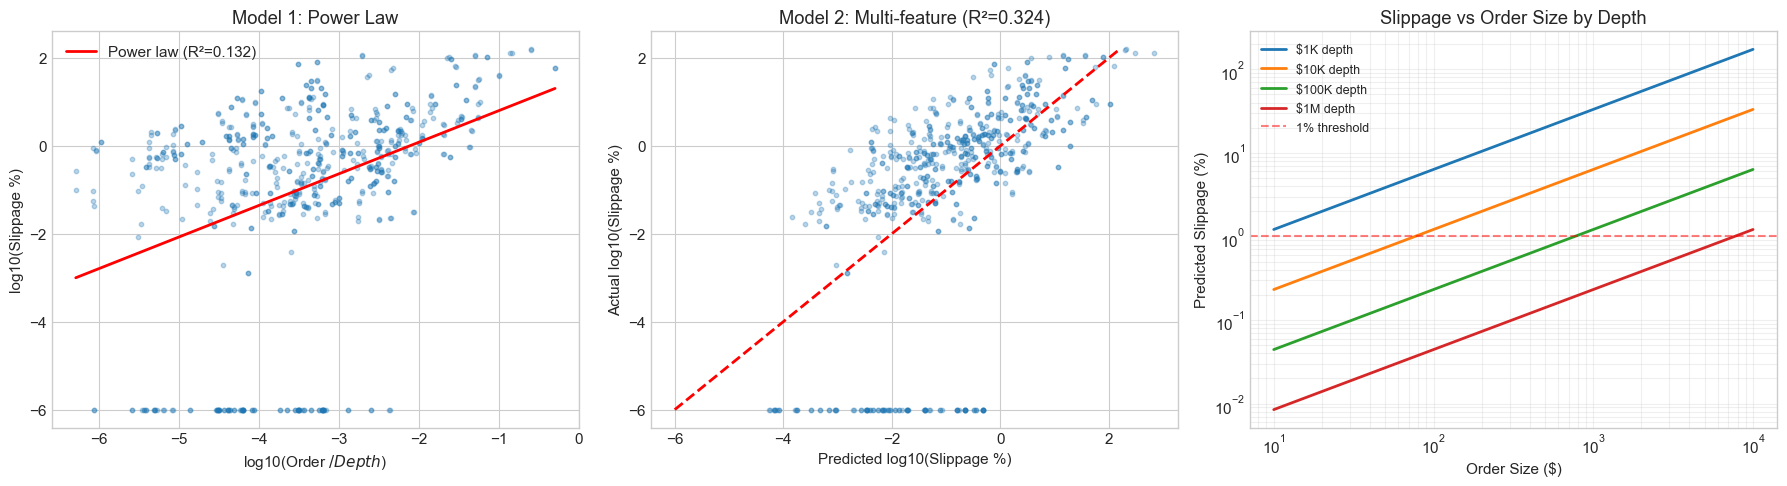

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(x[mask], y[mask], alpha=0.3, s=10)
x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
axes[0].plot(x_line, intercept + slope * x_line, "r-", lw=2,
             label=f"Power law (R²={r_value**2:.3f})")
axes[0].set_xlabel("log10(Order $ / Depth $)")
axes[0].set_ylabel("log10(Slippage %)")
axes[0].set_title("Model 1: Power Law")
axes[0].legend()

y2_pred = lr.predict(X)
axes[1].scatter(y2_pred, y2, alpha=0.3, s=10)
axes[1].plot([y2.min(), y2.max()], [y2.min(), y2.max()], "r--", lw=2)
axes[1].set_xlabel("Predicted log10(Slippage %)")
axes[1].set_ylabel("Actual log10(Slippage %)")
axes[1].set_title(f"Model 2: Multi-feature (R²={r2_multi:.3f})")

for depth_label, depth_val in [("$1K depth", 1000), ("$10K depth", 10000),
                                ("$100K depth", 100000), ("$1M depth", 1000000)]:
    orders = np.logspace(1, 4, 50)
    slippages = [10**(intercept + slope * np.log10(o / depth_val)) for o in orders]
    axes[2].plot(orders, slippages, label=depth_label, lw=2)

axes[2].axhline(1.0, color="r", ls="--", alpha=0.5, label="1% threshold")
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel("Order Size ($)")
axes[2].set_ylabel("Predicted Slippage (%)")
axes[2].set_title("Slippage vs Order Size by Depth")
axes[2].legend(fontsize=9)
axes[2].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
prices_sorted = prices.sort_values(["token_id", "datetime"]).copy()
prices_sorted["return"] = prices_sorted.groupby("token_id")["price"].diff()
prices_sorted["return_pct"] = prices_sorted.groupby("token_id")["price"].pct_change()

THRESHOLD = 0.10

crashes = prices_sorted[prices_sorted["return"] <= -THRESHOLD].copy()

spikes = prices_sorted[prices_sorted["return"] >= THRESHOLD].copy()

print(f"Large drops (>={THRESHOLD}): {len(crashes)}")
print(f"Large spikes (>={THRESHOLD}): {len(spikes)}")
print(f"Total events: {len(crashes) + len(spikes)}")
print(f"\nDrop size: mean={crashes['return'].mean():.3f}, median={crashes['return'].median():.3f}")
print(f"Spike size: mean={spikes['return'].mean():.3f}, median={spikes['return'].median():.3f}")

Large drops (>=0.1): 144
Large spikes (>=0.1): 152
Total events: 296

Drop size: mean=-0.173, median=-0.160
Spike size: mean=0.169, median=0.160


In [10]:
def measure_recovery(prices_df, event_row, max_hours=72):
    """Measure recovery time after a large price move.

    Returns hours to 50% recovery and 100% recovery.
    """
    token = event_row["token_id"]
    event_time = event_row["datetime"]
    pre_price = event_row["price"] - event_row["return"]
    post_price = event_row["price"]
    move = event_row["return"]

    token_prices = prices_df[
        (prices_df["token_id"] == token) &
        (prices_df["datetime"] > event_time)
    ].sort_values("datetime").head(max_hours)

    if len(token_prices) == 0:
        return {"recovery_50_hours": np.nan, "recovery_100_hours": np.nan,
                "max_recovery_pct": 0.0}

    recovery_50_hours = np.nan
    recovery_100_hours = np.nan
    max_recovery_pct = 0.0

    for _, row in token_prices.iterrows():
        hours_elapsed = (row["datetime"] - event_time).total_seconds() / 3600

        if abs(move) < 1e-8:
            break

        recovery_pct = (row["price"] - post_price) / (-move) * 100
        max_recovery_pct = max(max_recovery_pct, recovery_pct)

        if pd.isna(recovery_50_hours) and recovery_pct >= 50:
            recovery_50_hours = hours_elapsed
        if pd.isna(recovery_100_hours) and recovery_pct >= 100:
            recovery_100_hours = hours_elapsed
            break

    return {
        "recovery_50_hours": recovery_50_hours,
        "recovery_100_hours": recovery_100_hours,
        "max_recovery_pct": max_recovery_pct,
    }

print("Analyzing crash recovery...")
crash_recovery = []
for _, event in crashes.iterrows():
    rec = measure_recovery(prices_sorted, event)
    rec["move_size"] = abs(event["return"])
    rec["price_level"] = event["price"]
    rec["type"] = "crash"
    crash_recovery.append(rec)

print("Analyzing spike recovery...")
spike_recovery = []
for _, event in spikes.iterrows():
    rec = measure_recovery(prices_sorted, event)
    rec["move_size"] = abs(event["return"])
    rec["price_level"] = event["price"]
    rec["type"] = "spike"
    spike_recovery.append(rec)

recovery_df = pd.DataFrame(crash_recovery + spike_recovery)
print(f"\nTotal recovery events analyzed: {len(recovery_df)}")
print(f"\n=== Recovery Statistics ===")
for event_type in ["crash", "spike"]:
    subset = recovery_df[recovery_df["type"] == event_type]
    r50 = subset["recovery_50_hours"].dropna()
    r100 = subset["recovery_100_hours"].dropna()
    print(f"\n{event_type.upper()} ({len(subset)} events):")
    print(f"  50% recovery: {len(r50)}/{len(subset)} ({100*len(r50)/len(subset):.0f}%) achieved")
    if len(r50) > 0:
        print(f"    Median: {r50.median():.1f}h, Mean: {r50.mean():.1f}h")
    print(f"  100% recovery: {len(r100)}/{len(subset)} ({100*len(r100)/len(subset):.0f}%) achieved")
    if len(r100) > 0:
        print(f"    Median: {r100.median():.1f}h, Mean: {r100.mean():.1f}h")
    print(f"  Max recovery %: median={subset['max_recovery_pct'].median():.0f}%, mean={subset['max_recovery_pct'].mean():.0f}%")

Analyzing crash recovery...


Analyzing spike recovery...



Total recovery events analyzed: 296

=== Recovery Statistics ===

CRASH (144 events):
  50% recovery: 112/144 (78%) achieved
    Median: 2.0h, Mean: 8.5h
  100% recovery: 91/144 (63%) achieved
    Median: 11.0h, Mean: 16.1h
  Max recovery %: median=100%, mean=92%

SPIKE (152 events):
  50% recovery: 115/152 (76%) achieved
    Median: 2.0h, Mean: 9.1h
  100% recovery: 91/152 (60%) achieved
    Median: 11.0h, Mean: 16.1h
  Max recovery %: median=100%, mean=89%


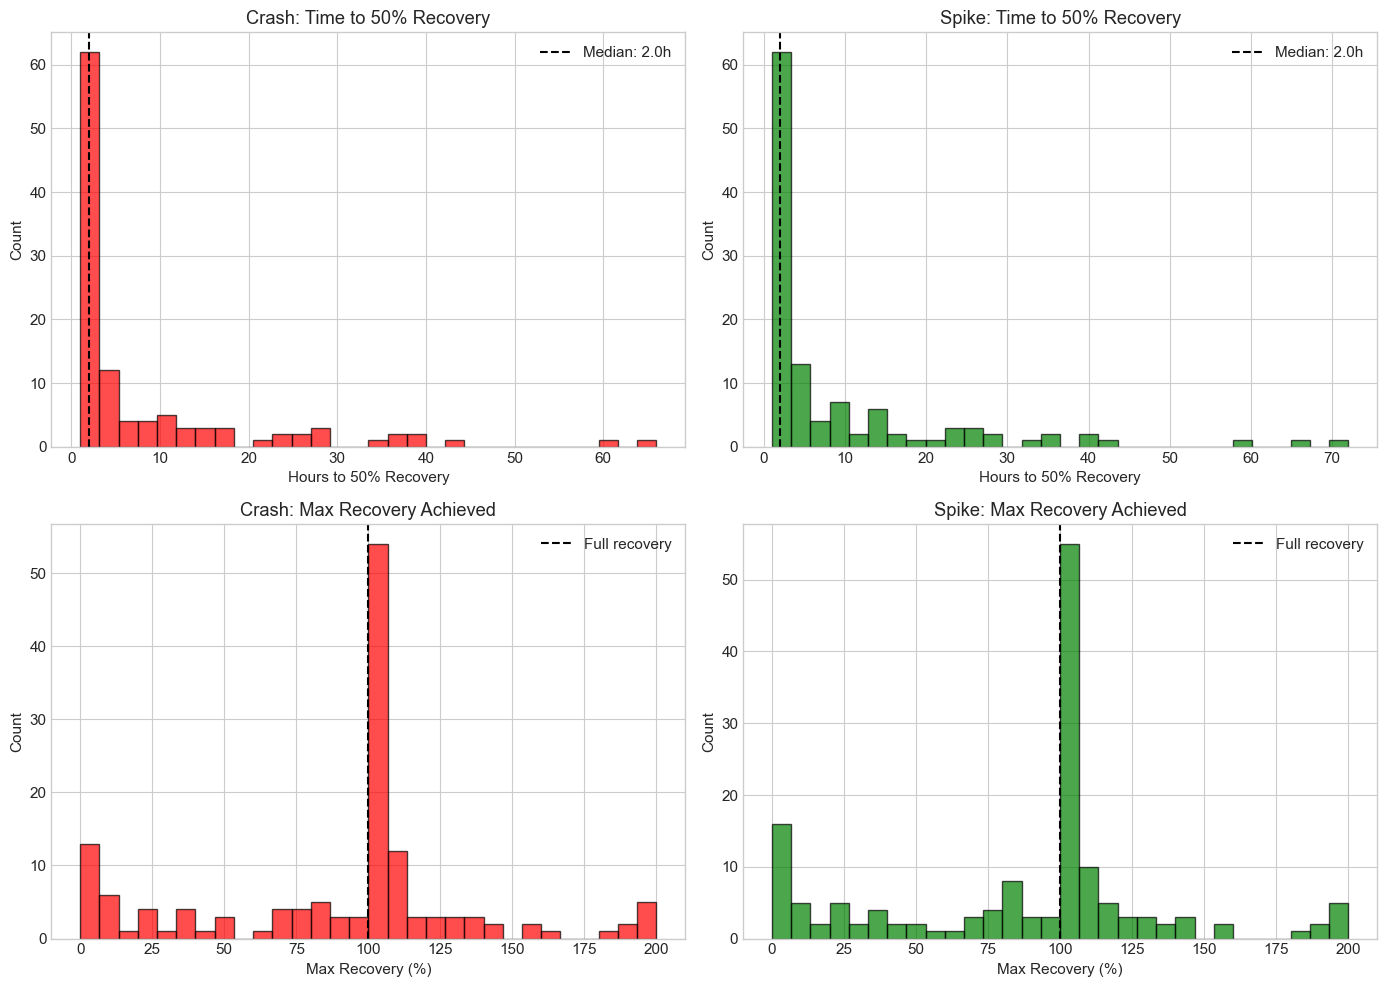

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, event_type in enumerate(["crash", "spike"]):
    subset = recovery_df[recovery_df["type"] == event_type]
    r50 = subset["recovery_50_hours"].dropna()
    if len(r50) > 0:
        axes[0, i].hist(r50.clip(upper=72), bins=30, edgecolor="k", alpha=0.7,
                       color="red" if event_type == "crash" else "green")
        axes[0, i].axvline(r50.median(), color="k", ls="--", label=f"Median: {r50.median():.1f}h")
        axes[0, i].set_xlabel("Hours to 50% Recovery")
        axes[0, i].set_ylabel("Count")
        axes[0, i].set_title(f"{event_type.title()}: Time to 50% Recovery")
        axes[0, i].legend()

for i, event_type in enumerate(["crash", "spike"]):
    subset = recovery_df[recovery_df["type"] == event_type]
    axes[1, i].hist(subset["max_recovery_pct"].clip(upper=200), bins=30,
                   edgecolor="k", alpha=0.7,
                   color="red" if event_type == "crash" else "green")
    axes[1, i].axvline(100, color="k", ls="--", label="Full recovery")
    axes[1, i].set_xlabel("Max Recovery (%)")
    axes[1, i].set_ylabel("Count")
    axes[1, i].set_title(f"{event_type.title()}: Max Recovery Achieved")
    axes[1, i].legend()

plt.tight_layout()
plt.show()

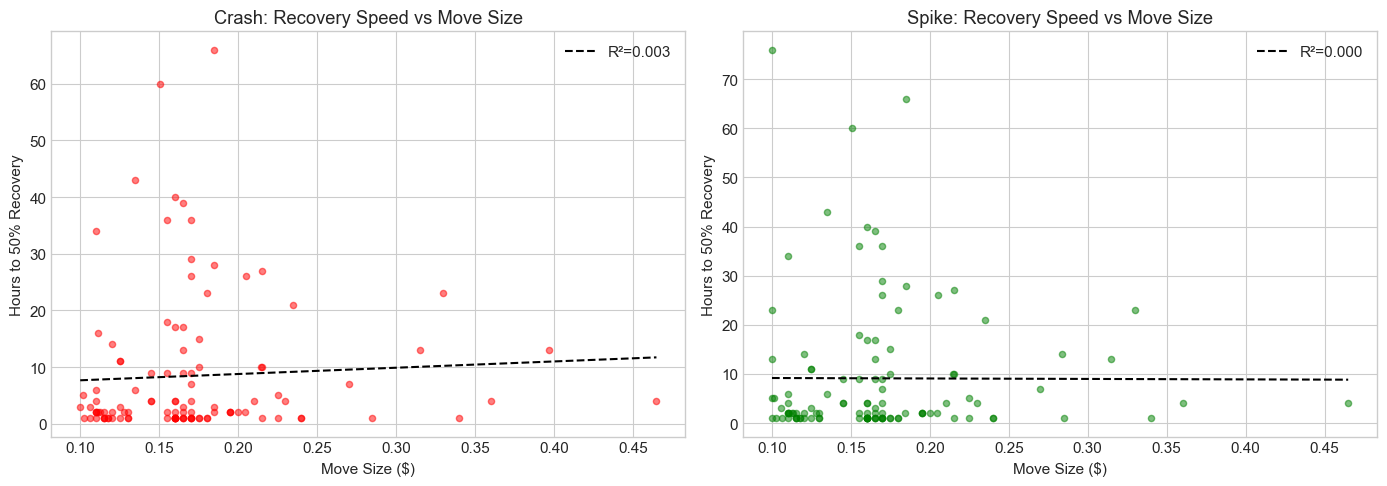


=== Recovery by Move Size ===
                   n_events  pct_recover_50  median_hours_50  pct_recover_100
type  move_bucket                                                            
crash 0.10-0.15          57            64.9              2.0             50.9
      0.15-0.20          58            93.1              2.0             79.3
      0.20-0.30          20            75.0              4.0             65.0
      0.30-0.50           9            66.7              8.5             33.3
spike 0.10-0.15          61            67.2              2.0             50.8
      0.15-0.20          61            86.9              2.0             73.8
      0.20-0.30          21            76.2              4.5             61.9
      0.30-0.50           8            62.5              4.0             25.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, event_type in enumerate(["crash", "spike"]):
    subset = recovery_df[(recovery_df["type"] == event_type) &
                         recovery_df["recovery_50_hours"].notna()]
    if len(subset) > 5:
        axes[i].scatter(subset["move_size"], subset["recovery_50_hours"],
                       alpha=0.5, s=20, color="red" if event_type == "crash" else "green")

        slope_r, intercept_r, r_val, _, _ = stats.linregress(
            subset["move_size"], subset["recovery_50_hours"])
        x_line = np.linspace(subset["move_size"].min(), subset["move_size"].max(), 50)
        axes[i].plot(x_line, intercept_r + slope_r * x_line, "k--",
                    label=f"R²={r_val**2:.3f}")
    axes[i].set_xlabel("Move Size ($)")
    axes[i].set_ylabel("Hours to 50% Recovery")
    axes[i].set_title(f"{event_type.title()}: Recovery Speed vs Move Size")
    axes[i].legend()

plt.tight_layout()
plt.show()

recovery_df["move_bucket"] = pd.cut(recovery_df["move_size"],
                                     bins=[0.10, 0.15, 0.20, 0.30, 0.50, 1.0],
                                     labels=["0.10-0.15", "0.15-0.20", "0.20-0.30", "0.30-0.50", "0.50+"])

print("\n=== Recovery by Move Size ===")
summary = recovery_df.groupby(["type", "move_bucket"]).agg(
    n_events=("move_size", "count"),
    pct_recover_50=("recovery_50_hours", lambda x: x.notna().mean() * 100),
    median_hours_50=("recovery_50_hours", "median"),
    pct_recover_100=("recovery_100_hours", lambda x: x.notna().mean() * 100),
).round(1)
print(summary.to_string())

In [13]:
print("=" * 60)
print("PHASE 2.4 RISK ANALYSIS — CONCLUSIONS")
print("=" * 60)

print(f"\n--- Data: {len(all_snapshots)} orderbook snapshots, {n_rounds} collection rounds ---")

print("\n--- Slippage Models ---")
print(f"Model 1 (power law): slippage = {10**intercept:.2f} * (order/depth)^{slope:.2f}, R²={r_value**2:.3f}")
print(f"Model 2 (multi-feature): R²={r2_multi:.3f} (adds midpoint, price_extremity, spread)")

print(f"\nMedian slippage by order size:")
for size in ORDER_SIZES:
    med = slip_df[slip_df["order_usd"] == size]["avg_slippage_pct"].median()
    fill = slip_df[slip_df["order_usd"] == size]["buy_filled_pct"].mean()
    print(f"  ${size:>5}: {med:.3f}% slippage, {fill:.0%} fill rate")

print("\n--- Recovery Time ---")
for event_type in ["crash", "spike"]:
    subset = recovery_df[recovery_df["type"] == event_type]
    r50 = subset["recovery_50_hours"].dropna()
    r100 = subset["recovery_100_hours"].dropna()
    print(f"\n{event_type.upper()}: {len(subset)} events")
    if len(r50) > 0:
        print(f"  50% recovery: median {r50.median():.1f}h ({100*len(r50)/len(subset):.0f}% achieve)")
    if len(r100) > 0:
        print(f"  Full recovery: median {r100.median():.1f}h ({100*len(r100)/len(subset):.0f}% achieve)")

print("\n--- Features for Phase 3 ---")
print("1. slippage_estimate: predicted slippage from order/depth model")
print("2. orderbook_depth_5c: dollar depth within 5c of best price")
print("3. price_extremity: 4*p*(1-p), captures thin-book risk at extreme prices")
print("4. recovery_speed: historical hours-to-50%-recovery for this market")
print("5. is_recovering: flag if price recently had >$0.10 move")

print("\n--- Implications for Strategy ---")
print("• Orders <$100 in TOP-50 markets: near-zero slippage")
print("• Orders >$1K: need depth >$100K for <1% slippage")
print("• Flash crash strategy: buy the dip, 50% recovery in ~2h")
print(f"• {recovery_df[recovery_df['type']=='crash']['recovery_100_hours'].notna().mean():.0%} of crashes fully recover → viable mean-reversion signal")
print("• Extreme-price markets have asymmetric depth → higher slippage risk")
print("• Phase 5: use slippage model for order size optimization")

PHASE 2.4 RISK ANALYSIS — CONCLUSIONS

--- Data: 200 orderbook snapshots, 2 collection rounds ---

--- Slippage Models ---
Model 1 (power law): slippage = 33.13 * (order/depth)^0.72, R²=0.132
Model 2 (multi-feature): R²=0.324 (adds midpoint, price_extremity, spread)

Median slippage by order size:
  $   10: 0.000% slippage, 100% fill rate
  $   50: 0.000% slippage, 100% fill rate
  $  100: 0.000% slippage, 100% fill rate
  $  500: 0.040% slippage, 100% fill rate
  $ 1000: 0.101% slippage, 100% fill rate
  $ 5000: 0.671% slippage, 100% fill rate

--- Recovery Time ---

CRASH: 144 events
  50% recovery: median 2.0h (78% achieve)
  Full recovery: median 11.0h (63% achieve)

SPIKE: 152 events
  50% recovery: median 2.0h (76% achieve)
  Full recovery: median 11.0h (60% achieve)

--- Features for Phase 3 ---
1. slippage_estimate: predicted slippage from order/depth model
2. orderbook_depth_5c: dollar depth within 5c of best price
3. price_extremity: 4*p*(1-p), captures thin-book risk at extr